In [1]:
import keras
from keras import layers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score
from metrics_tracking import F1Score, plot_metrics


In [4]:
OTIDS_file_colab = "OTIDS_clean_data.npz"
OTIDS_file_local = "Preprocessed_Data/OTIDS_clean_data.npz"
data = np.load(OTIDS_file_local)
# Access arrays by the names you used when saving
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
y_train = y_train.astype("int32").ravel()
y_test  = y_test.astype("int32").ravel()

In [5]:
def create_model_otids_best():
    inp = keras.Input(shape=(600, 11))
    x = layers.Conv1D(64, 12, activation='relu')(inp)
    x_max = layers.GlobalMaxPooling1D()(x)
    x_avg = layers.GlobalAveragePooling1D()(x)
    x = layers.Concatenate()([x_max, x_avg])
    x = layers.Dense(32, activation='relu')(x)   # optional small dense
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    return model
best_otids_model = create_model_otids_best()


In [6]:
#1d cnn sequential model used for comparison with ROAD 
def create_model_otids(num_filters=128, kernel=8): #this is the same model we'll always use for all.
    model = keras.Sequential()
    model.add(layers.Input(shape=(600, 11)))
    model.add(layers.Conv1D(128, 8, activation='relu'))
    model.add(layers.GlobalAveragePooling1D()) #was GlobalMaxPooling1D
    model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
    return model

filters = 128#96 #
kernel_size = 8#16 #
model = create_model_otids(filters, kernel_size)

In [7]:
callbacks = [
    ModelCheckpoint("saved_models/best_model_OTIDS_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-12, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, verbose=1, restore_best_weights=True)
]
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="binary_crossentropy",   # correct for sigmoid + 0/1 labels
    metrics=[
        keras.metrics.AUC(name="auc"),
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        F1Score(name="f1")
    ]
)
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
956/957 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5317 - auc: 0.5443 - f1: 0.6030 - loss: 0.6892 - precision: 0.5300 - recall: 0.7068
Epoch 1: val_auc improved from None to 0.77226, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.5659 - auc: 0.5929 - f1: 0.6313 - loss: 0.6826 - precision: 0.5596 - recall: 0.7242 - val_accuracy: 0.5488 - val_auc: 0.7723 - val_f1: 0.6951 - val_loss: 0.6639 - val_precision: 0.5339 - val_recall: 0.9960 - learning_rate: 5.0000e-04
Epoch 2/50
955/957 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6363 - auc: 0.6974 - f1: 0.6798 - loss: 0.6533 - precision: 0.6250 - recall: 0.7480
Epoch 2: val_auc improved from 0.77226 to 0.77348, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.6476 - auc: 0.7082 - f1: 0.6752 - loss: 0.6443 - precision: 0.6407 - recall: 0.7135 - val_accuracy: 0.6138 - val_auc: 0.7735 - val_f1

KeyboardInterrupt: 

In [ ]:
testing_acc = model.evaluate(X_test,y_test, verbose=1)
print(f"Test AUC: {testing_acc[2]}")
print(f"Test Accuracy: {testing_acc[1]}")
print(f"Test Precision: {testing_acc[3]}")
print(f"Test Recall: {testing_acc[4]}")
print(f"Test F1: {testing_acc[5]}")
print(f"Test Loss: {testing_acc[0]}")


266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7017 - auc: 0.7796 - f1: 0.6897 - loss: 0.5668 - precision: 0.7405 - recall: 0.6454
Test AUC: 0.7016698122024536
Test accuracy: 0.7795883417129517
Test Precision: 0.7404780387878418
Test Recall: 0.6453754305839539
Test F1: 0.6896634697914124
Test loss: 0.5667663812637329


In [8]:
model_save_name = "best_OTIDS_model128.keras"
model.save(model_save_name)

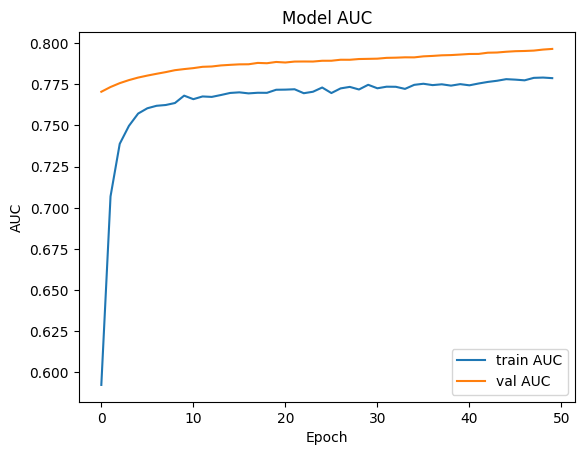

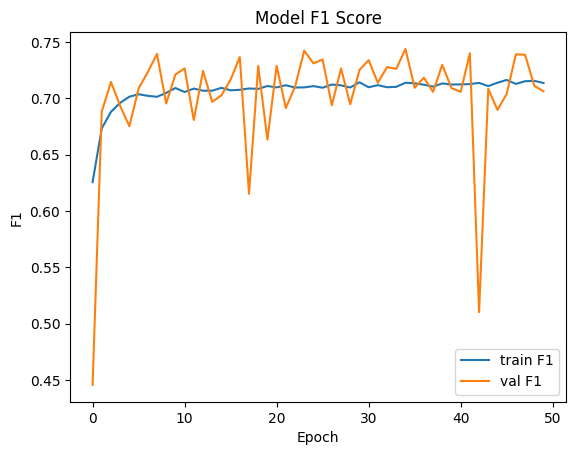

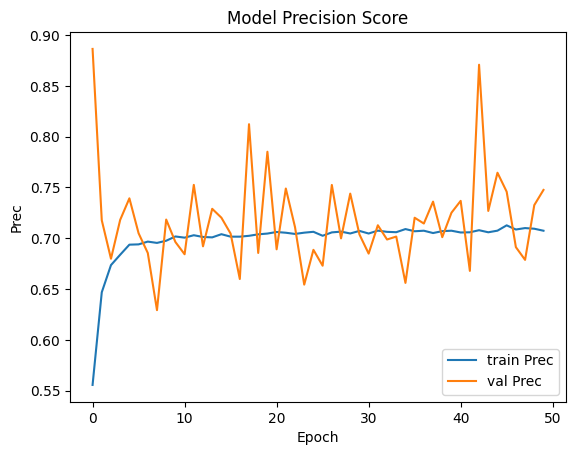

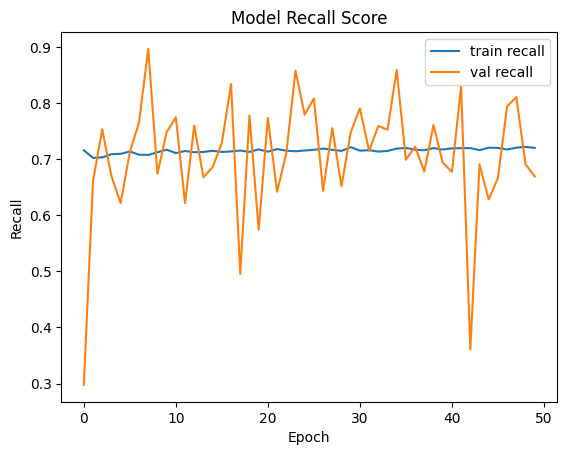

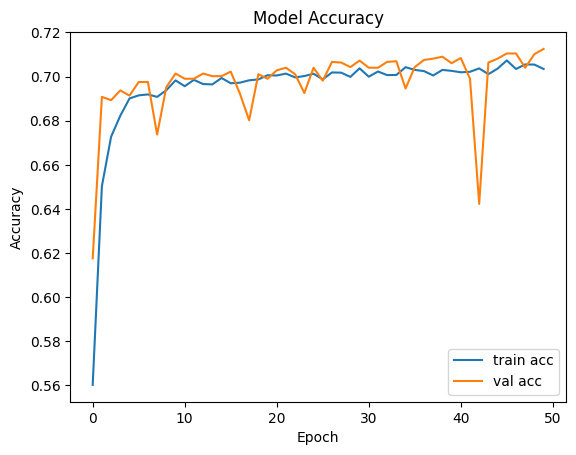

In [9]:
plot_metrics(history, model_save_name)

In [13]:

def print_report_and_score(model, X_test, y_test):
    y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
    y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold
    print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    return y_pred
y_pred = print_report_and_score(model, X_test, y_test)

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

     Ambient       0.67      0.76      0.71      4136
      Attack       0.74      0.65      0.69      4368

    accuracy                           0.70      8504
   macro avg       0.71      0.70      0.70      8504
weighted avg       0.71      0.70      0.70      8504

ROC AUC Score: 0.7796


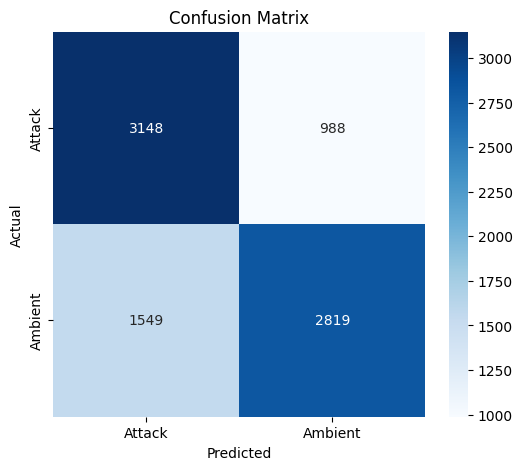

In [16]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Attack", "Ambient"],
    yticklabels=["Attack", "Ambient"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


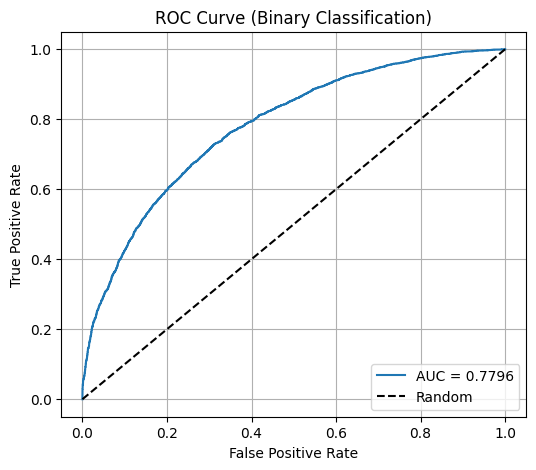

<Figure size 640x480 with 0 Axes>

In [12]:
#current matrix above is for OTIDS_128 kernel size

from sklearn.metrics import roc_curve


y_pred_proba = model.predict(X_test).ravel()   # shape (N,)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.savefig("plots/ROC_AUC_CURVE_OTIDS.png", dpi=300, bbox_inches="tight")